The mouse hippocampus Slide-seqV2 data: [gene expression data and BAM files](https://singlecell.broadinstitute.org/single_cell/study/SCP815/highly-sensitive-spatial-transcriptomics-at-near-cellular-resolution-with-slide-seqv2).

The loom files of unspliced and spliced counts was processed from the BAM files by [Velocyto](https://github.com/velocyto-team/velocyto.py).

In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import os
import seaborn as sns
import matplotlib.pyplot as plt
import STAVelo as stv
stv.settings.verbosity = 3
stv.settings.presenter_view = True
stv.set_figure_params("scvelo")
import warnings
warnings.filterwarnings("ignore")

# Read data

In [2]:
label_df=pd.read_csv("../data/T2_Mouse_Brain_Slideseq_Puck20011508/adata_obs_annotation.csv", index_col=0)
coor_df=pd.read_csv("../data/T2_Mouse_Brain_Slideseq_Puck20011508/Puck_200115_08_bead_locations.csv", 
                    sep=",", skiprows=[0], header=None, index_col=0)
coor_df.columns=["xcoord","ycoord"]
adata=sc.read_loom("../data/T2_Mouse_Brain_Slideseq_Puck20011508/Puck_200115_08_OAM2I.loom")
adata.obs.index = adata.obs.index.str.replace("Puck_200115_08_OAM2I:", "", regex=False)
adata=adata[adata.obs_names.isin(coor_df.index)]
adata.obs[['xcoord', 'ycoord', 'label']]=label_df.loc[label_df.index, ['xcoord', 'ycoord', 'annotation_rough']]
adata.obs['label'] = adata.obs['label'].astype(str)
adata.obsm["spatial"] = adata.obs[['xcoord', 'ycoord']].to_numpy()

In [3]:
categories_order=['Cerebral cortex', 'Fiber tracts', 'Hippocampus', 'Thalamus','Ventricle','UNK']
adata.obs['label'] = adata.obs['label'].astype(pd.CategoricalDtype(categories=categories_order, ordered=False))
adata.uns["label_colors"]=['#018435','#97d6f9','#ad40ff','#8c564b','#e377c2','#808080']

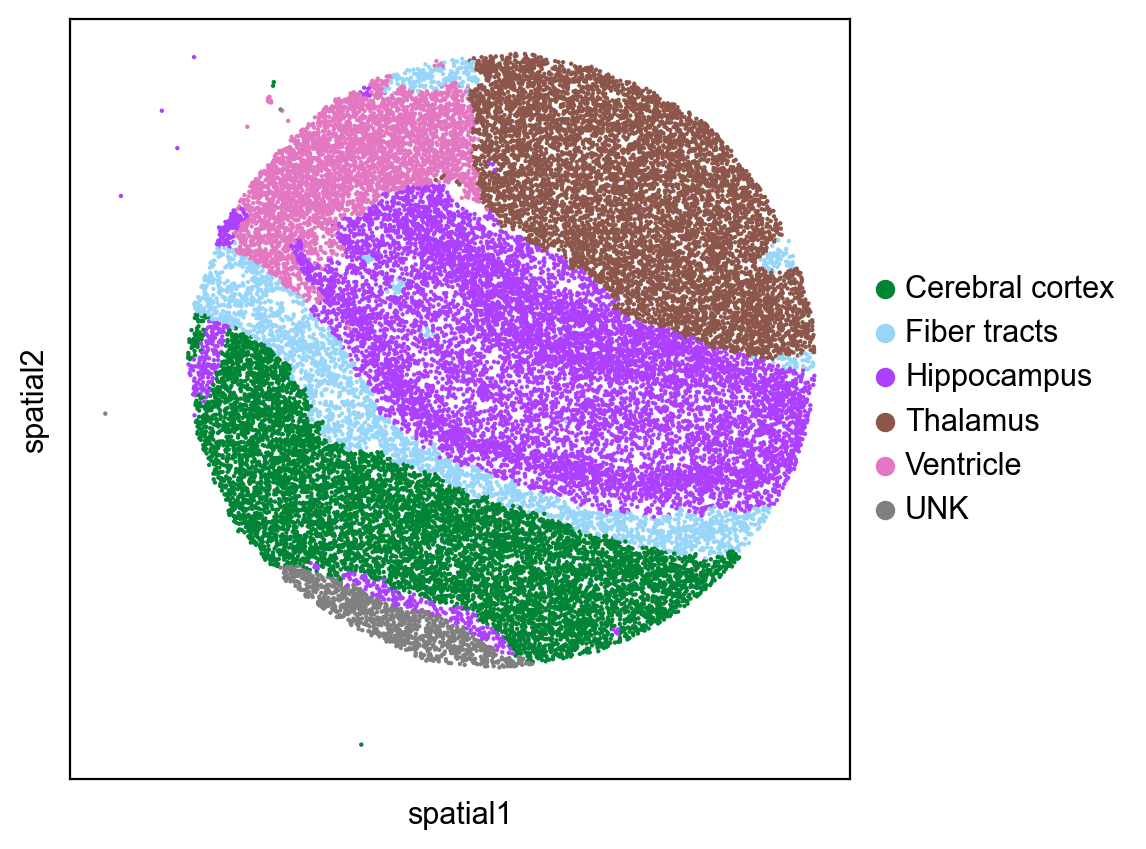

In [4]:
plt.rcParams["figure.figsize"] = (5, 5)
sc.pl.embedding(adata, basis="spatial", color="label", title="", s=10)

# Run model

In [5]:
stv.show_proportions(adata)
adata

Abundance of ['unspliced', 'spliced', 'ambiguous']: [0.07 0.86 0.07]


AnnData object with n_obs × n_vars = 27798 × 56305
    obs: 'xcoord', 'ycoord', 'label'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    uns: 'label_colors'
    obsm: 'spatial'
    layers: 'matrix', 'ambiguous', 'spliced', 'unspliced'

In [6]:
stv.filter_and_normalize(adata, min_shared_counts=2, n_top_genes=1000)
stv.moments(adata, n_pcs=30, n_neighbors=30)

Filtered out 49621 genes that are detected 2 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 1000 highly variable genes.
Logarithmized X.
computing neighbors
    finished (0:00:30) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:01) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [7]:
stv.Cal_Spatial_Net(adata, rad_cutoff=50)

------Calculating spatial graph...
The graph contains 339116 edges, 27798 cells.
12.1993 neighbors per cell on average.


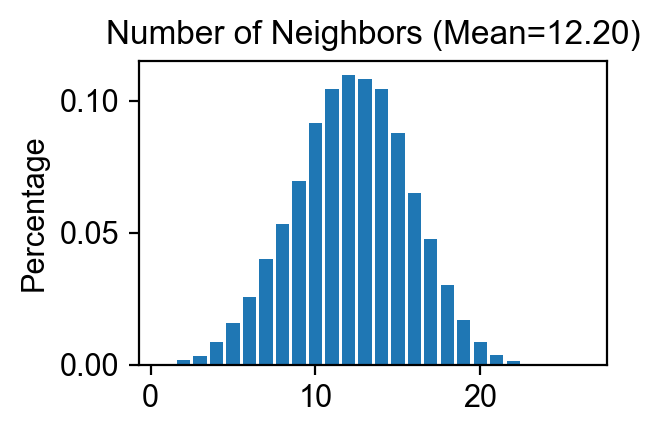

In [8]:
stv.Stats_Spatial_Net(adata)

In [9]:
adata = stv.train_STAVelo(adata, loss_type="cosine", w1 = 1, w2 = 1, random_seed=0, device = 'cuda:0')

Size of Input:  (27789, 1000)


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [01:29<00:00, 11.21it/s]


In [10]:
stv.velocity_graph(adata, n_neighbors=2000, n_jobs=16)

computing velocity graph (using 16/384 cores)


  0%|          | 0/27789 [00:00<?, ?cells/s]

    finished (0:01:18) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


# Velocity visualization

In [11]:
#adata=sc.read("./result/adata.h5ad")

Renamed 'spatial' to convention 'X_spatial' (adata.obsm).
computing velocity embedding
    finished (0:00:06) --> added
    'velocity_spatial', embedded velocity vectors (adata.obsm)


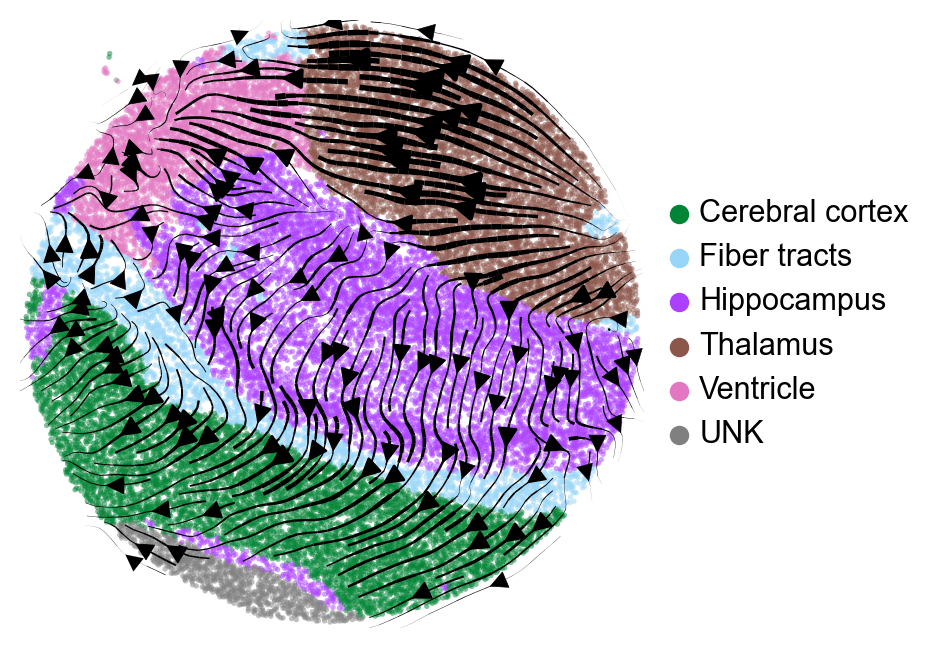

In [12]:
plt.rcParams["figure.figsize"] = (4, 4)
stv.velocity_embedding_stream(adata, basis='spatial', color="label", title="", legend_loc="right", alpha=0.5, size=15,
                              linewidth=1.5, arrow_size=1.5)

In [13]:
#if not os.path.exists("./result"):
#    os.makedirs("./result")
#adata.write("./result/adata.h5ad")